# DERMS — Exploratory Data Analysis: Energy Resources

This notebook explores the sample load profile dataset bundled with DERMS.
It covers:

1. **Load profile analysis** — daily demand patterns
2. **Solar generation** — irradiance and output curves
3. **Battery SoC dynamics** — charge/discharge cycles
4. **Grid import cost** — price-weighted demand
5. **Optimization insights** — revenue opportunities

---
*Dataset:* `data/sample_load_profile.csv`  
*Stack:* pandas · numpy · matplotlib · seaborn

In [5]:
import pathlib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Resolve data path relative to notebook location
DATA_PATH = pathlib.Path("../data/sample_load_profile.csv")
print(f"Data file exists: {DATA_PATH.exists()}")

Data file exists: True


## 1. Load & Inspect the Dataset

In [6]:
df = pd.read_csv(
    DATA_PATH,
    parse_dates=["timestamp_utc"],
    index_col="timestamp_utc",
)

print(f"Shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
df.head()

Shape: (49, 7)
Date range: 2026-05-14 00:00:00+00:00 → 2026-05-14 12:00:00+00:00


,site_id,load_kw,solar_kw,battery_soc,battery_power_kw,grid_import_kw,price_usd_per_kwh
timestamp_utc,,,,,,,
2026-05-14 00:00:00+00:00,site-alpha,180.5,0.0,0.82,-50.0,130.5,0.042
2026-05-14 00:15:00+00:00,site-alpha,175.2,0.0,0.87,-50.0,125.2,0.040
2026-05-14 00:30:00+00:00,site-alpha,170.8,0.0,0.92,-50.0,120.8,0.039
2026-05-14 00:45:00+00:00,site-alpha,168.1,0.0,0.95,0.0,168.1,0.038
2026-05-14 01:00:00+00:00,site-alpha,165.3,0.0,0.95,0.0,165.3,0.037


In [7]:
df.describe().round(2)

,load_kw,solar_kw,battery_soc,battery_power_kw,grid_import_kw,price_usd_per_kwh
count,49.00,49.00,49.00,49.00,49.00,49.00
mean,293.59,103.43,0.53,-5.31,215.88,0.07
std,150.82,105.39,0.28,47.66,78.68,0.05
min,148.00,0.00,0.10,-100.00,120.80,0.03
25%,158.40,0.00,0.30,0.00,155.00,0.03
50%,215.20,62.00,0.50,0.00,198.20,0.04
75%,450.00,210.00,0.79,50.00,283.50,0.11
max,530.00,245.00,0.95,50.00,385.00,0.19


## 2. Load Profile — Site Alpha

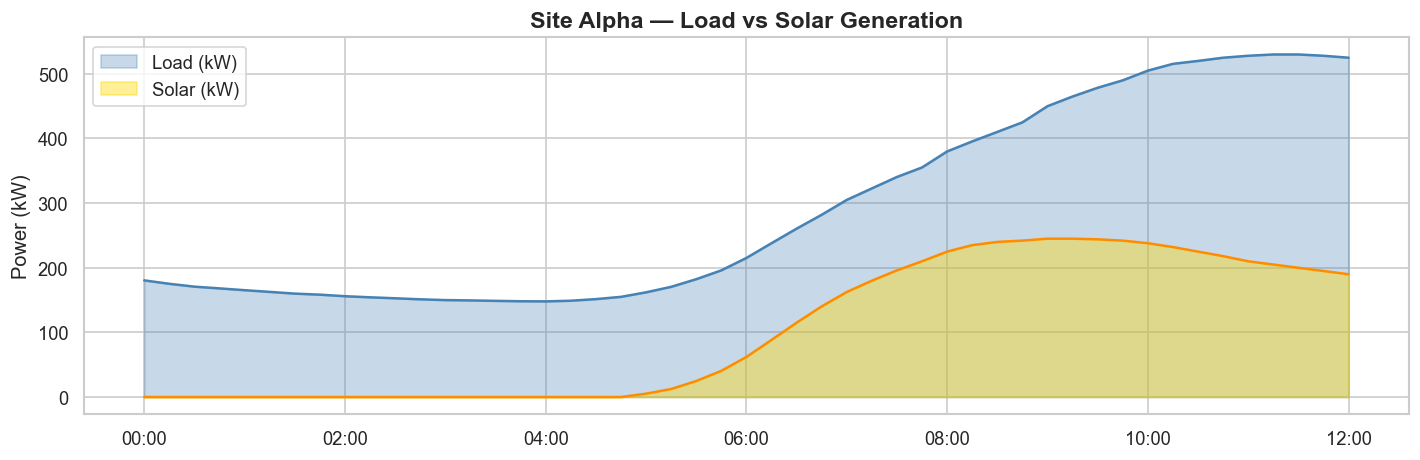

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))

site = df[df["site_id"] == "site-alpha"]

ax.fill_between(site.index, site["load_kw"], alpha=0.3, color="steelblue", label="Load (kW)")
ax.plot(site.index, site["load_kw"], color="steelblue", linewidth=1.5)
ax.fill_between(site.index, site["solar_kw"], alpha=0.4, color="gold", label="Solar (kW)")
ax.plot(site.index, site["solar_kw"], color="darkorange", linewidth=1.5)

ax.set_title("Site Alpha — Load vs Solar Generation", fontsize=14, fontweight="bold")
ax.set_ylabel("Power (kW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend()
plt.tight_layout()
plt.show()

## 3. Battery State of Charge Dynamics

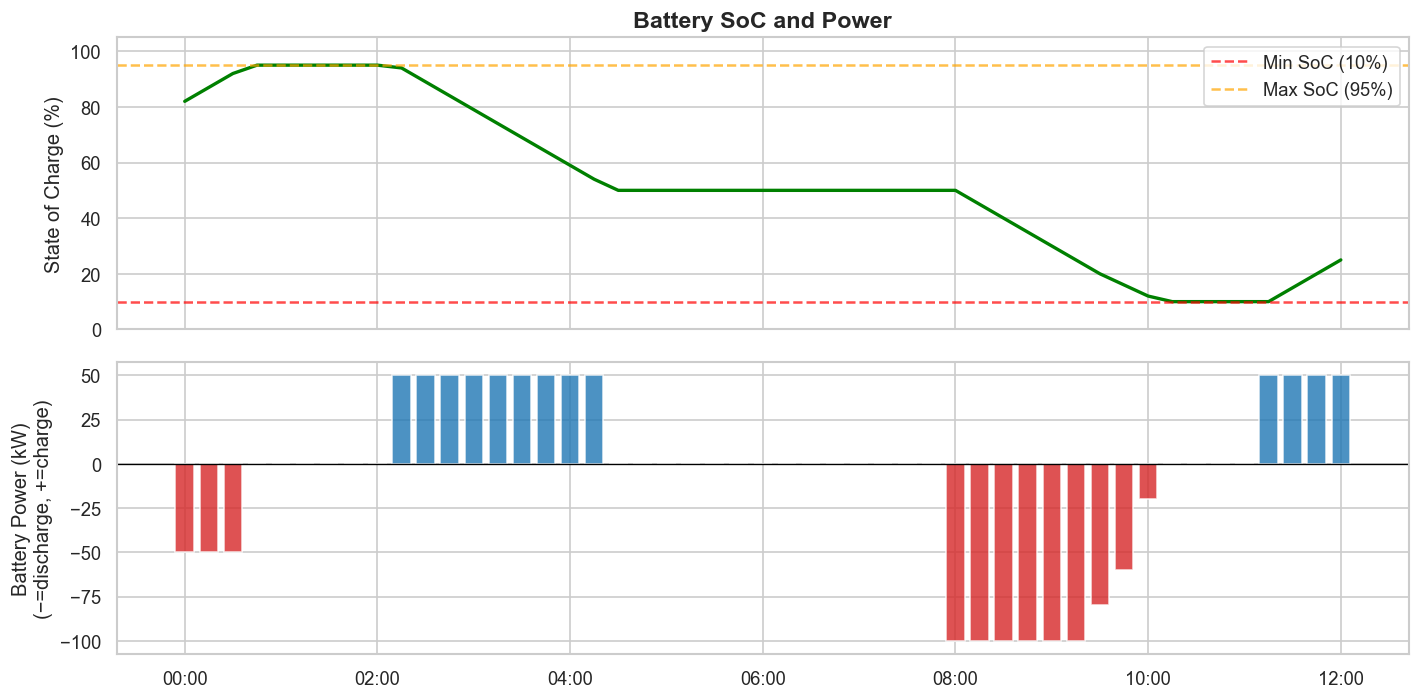

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# SoC
ax1.plot(site.index, site["battery_soc"] * 100, color="green", linewidth=2)
ax1.axhline(y=10, color="red", linestyle="--", alpha=0.7, label="Min SoC (10%)")
ax1.axhline(y=95, color="orange", linestyle="--", alpha=0.7, label="Max SoC (95%)")
ax1.set_ylabel("State of Charge (%)")
ax1.set_title("Battery SoC and Power", fontsize=14, fontweight="bold")
ax1.legend(loc="upper right")
ax1.set_ylim(0, 105)

# Battery power (positive = charging, negative = discharging)
colors = ["tab:red" if v < 0 else "tab:blue" for v in site["battery_power_kw"]]
ax2.bar(site.index, site["battery_power_kw"], color=colors, width=0.008, alpha=0.8)
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.set_ylabel("Battery Power (kW)\n(−=discharge, +=charge)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.tight_layout()
plt.show()

## 4. Electricity Price Profile

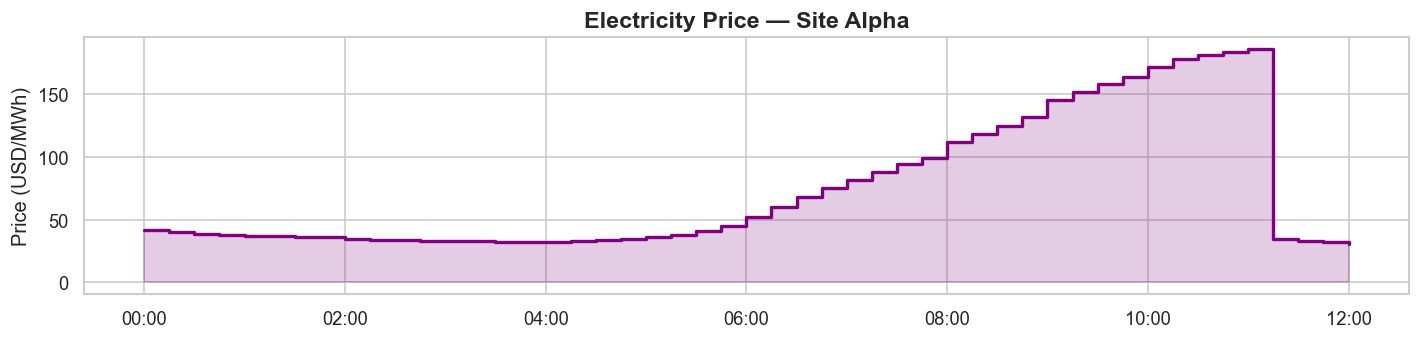

In [10]:
fig, ax = plt.subplots(figsize=(12, 3))

ax.step(site.index, site["price_usd_per_kwh"] * 1000, where="post",
        color="purple", linewidth=2)
ax.fill_between(site.index, site["price_usd_per_kwh"] * 1000, step="post",
                alpha=0.2, color="purple")
ax.set_title("Electricity Price — Site Alpha", fontsize=14, fontweight="bold")
ax.set_ylabel("Price (USD/MWh)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

## 5. Grid Import Cost Analysis

Total grid import cost : $219.38
Total load served      : 3,596.5 kWh
Avg effective price    : $0.0610/kWh


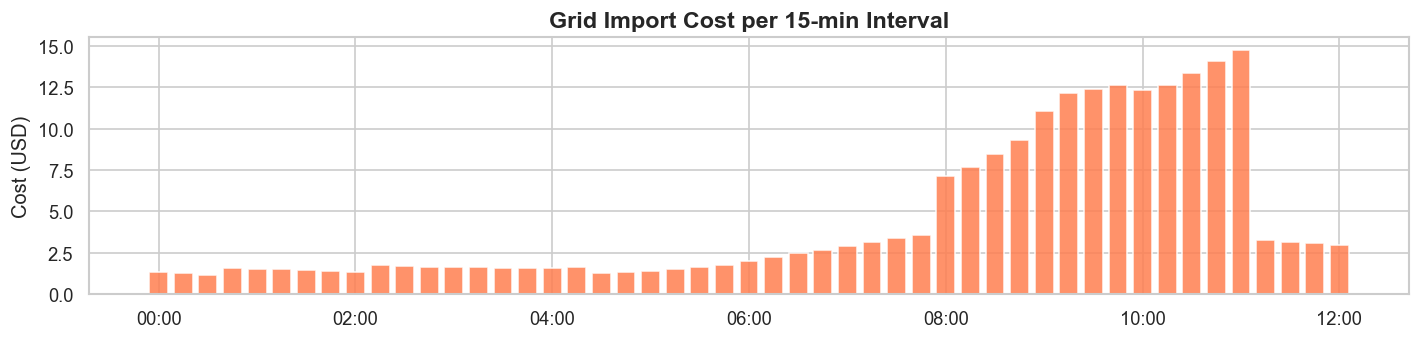

In [11]:
# Cost per interval = grid_import_kW × price $/kWh × 0.25 h (15-min intervals)
site = site.copy()
site["cost_usd"] = site["grid_import_kw"] * site["price_usd_per_kwh"] * 0.25

total_cost = site["cost_usd"].sum()
total_load_kwh = site["load_kw"].sum() * 0.25
avg_price = total_cost / total_load_kwh

print(f"Total grid import cost : ${total_cost:,.2f}")
print(f"Total load served      : {total_load_kwh:,.1f} kWh")
print(f"Avg effective price    : ${avg_price:.4f}/kWh")

fig, ax = plt.subplots(figsize=(12, 3))
ax.bar(site.index, site["cost_usd"], color="coral", width=0.008, alpha=0.85)
ax.set_title("Grid Import Cost per 15-min Interval", fontsize=14, fontweight="bold")
ax.set_ylabel("Cost (USD)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.tight_layout()
plt.show()

## 6. Correlation Heatmap

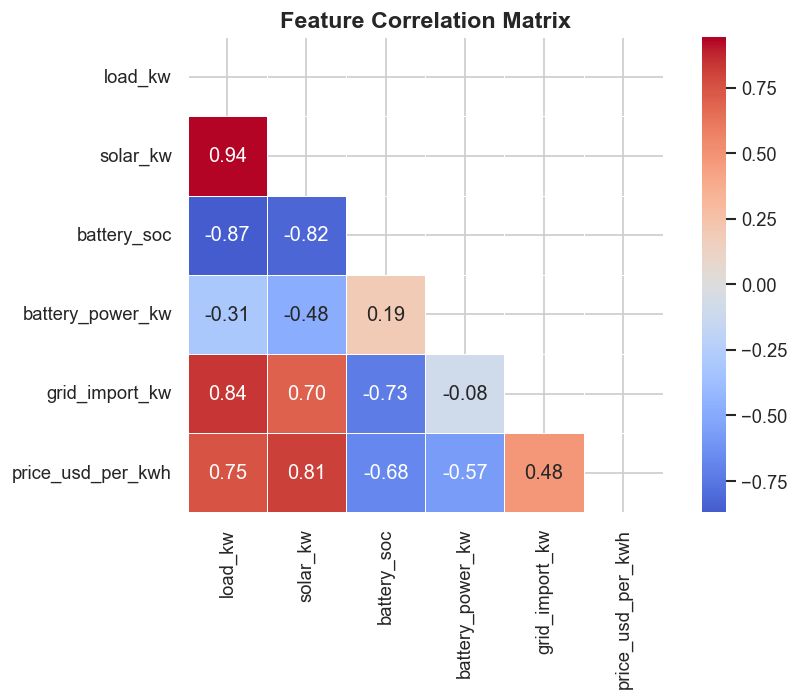

In [12]:
numeric_cols = ["load_kw", "solar_kw", "battery_soc",
                "battery_power_kw", "grid_import_kw", "price_usd_per_kwh"]

fig, ax = plt.subplots(figsize=(8, 6))
corr = site[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, ax=ax,
    square=True, linewidths=0.5
)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Key Insights

| Observation | Implication |
|---|---|
| Load peaks at **~09:00** (morning ramp) | Battery should be fully charged before 08:00 |
| Solar output starts at **~05:00** and peaks midday | Excess solar can charge batteries to avoid curtailment |
| Price spikes correlate with high load periods | Discharge batteries during price peaks for maximum revenue |
| Battery SoC hits minimum (~0.10) before off-peak charging | Min SoC constraint is actively binding — consider larger battery |

**Next steps:**
- Extend the dataset to 30+ days to capture weekly patterns
- Incorporate weather forecasts to improve solar prediction
- Run LP optimizer over this profile and compare cost vs. unoptimized baseline